# 07 - Threshold Selection and Business Costing

This notebook converts model scores into an operating decision rule for credit-risk review.

Notebook 06 selected the champion model using validation PR-AUC and supporting ranking metrics. This notebook now asks a more business-focused question: **which probability threshold should trigger manual credit review or risk intervention?**

## Professional framing

A default probability model is not useful until the business decides how to act on the score. In retail credit risk, threshold choice creates a trade-off:

- A lower threshold captures more potential defaults but sends more accounts to manual review.
- A higher threshold reduces review volume but misses more defaults.
- The correct threshold depends on loss appetite, operational capacity, regulatory expectations, and customer-impact considerations.

This notebook uses validation predictions only for threshold selection. The test split is used only after the threshold has been selected.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from credit_risk.config import TABLE_DIR, ensure_project_directories
from credit_risk.models.thresholding import (
    ThresholdCostAssumptions,
    apply_thresholds_to_dataset,
    build_threshold_grid,
    build_threshold_shortlist,
    cost_assumptions_frame,
    evaluate_threshold_grid_all_models,
    recommend_operating_threshold,
    save_threshold_outputs,
)

ensure_project_directories()

VALIDATION_PREDICTIONS_PATH = TABLE_DIR / "validation_predictions_default_threshold.csv"
TEST_PREDICTIONS_PATH = TABLE_DIR / "test_predictions_default_threshold.csv"
MODEL_SELECTION_PATH = TABLE_DIR / "model_selection_summary.csv"

## Load model predictions from Notebook 06

The threshold analysis uses saved validation and test prediction files. These files contain model names, borrower IDs, true target values, and predicted default probabilities.

In [2]:
validation_predictions = pd.read_csv(VALIDATION_PREDICTIONS_PATH, low_memory=False)
test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH, low_memory=False)
model_selection_summary = pd.read_csv(MODEL_SELECTION_PATH)

champion_model_name = str(model_selection_summary.sort_values("selection_rank").iloc[0]["model_name"])

load_summary = {
    "validation_prediction_rows": validation_predictions.shape[0],
    "test_prediction_rows": test_predictions.shape[0],
    "models_available": sorted(validation_predictions["model_name"].unique().tolist()),
    "champion_model": champion_model_name,
}
load_summary

{'validation_prediction_rows': 60489,
 'test_prediction_rows': 60489,
 'models_available': ['logistic_regression_balanced',
  'random_forest_balanced',
  'xgboost_weighted'],
 'champion_model': 'xgboost_weighted'}

## Define business-cost assumptions

These cost assumptions are illustrative and should be treated as a portfolio-risk scenario, not as accounting estimates. They help compare thresholds consistently.

In [3]:
cost_assumptions = ThresholdCostAssumptions(
    false_negative_cost=5_000,
    false_positive_cost=500,
)

cost_assumptions_df = cost_assumptions_frame(cost_assumptions)
cost_assumptions_df

,assumption,value,description
0,false_negative_cost,5000.000000,Illustrative cost of missing a borrower who la...
1,false_positive_cost,500.000000,Illustrative operational/customer-friction cos...
2,calibrated_probability_cost_ratio_threshold,0.090909,Theoretical cutoff if model probabilities were...


## Evaluate all candidate thresholds

The grid below tests thresholds from 0.01 to 0.99. Threshold selection is performed on validation data only.

In [4]:
thresholds = build_threshold_grid(start=0.01, stop=0.99, step=0.005)

validation_threshold_grid = evaluate_threshold_grid_all_models(
    validation_predictions,
    thresholds=thresholds,
    dataset_name="validation",
    cost_assumptions=cost_assumptions,
)

test_threshold_grid = evaluate_threshold_grid_all_models(
    test_predictions,
    thresholds=thresholds,
    dataset_name="test",
    cost_assumptions=cost_assumptions,
)

validation_threshold_grid.head()

,model_name,dataset,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,mcc,review_rate,business_cost,true_negative,false_positive,false_negative,true_positive,default_count,non_default_count
0,logistic_regression_balanced,validation,0.010,0.74439,0.219675,0.208386,0.090463,0.500027,0.090418,1.0,0.165840,0.002220,0.999950,9169500.0,1,18339,0,1823,1823,18340
1,logistic_regression_balanced,validation,0.015,0.74439,0.219675,0.208386,0.090463,0.500027,0.090418,1.0,0.165840,0.002220,0.999950,9169500.0,1,18339,0,1823,1823,18340
2,logistic_regression_balanced,validation,0.020,0.74439,0.219675,0.208386,0.090463,0.500027,0.090418,1.0,0.165840,0.002220,0.999950,9169500.0,1,18339,0,1823,1823,18340
3,logistic_regression_balanced,validation,0.025,0.74439,0.219675,0.208386,0.090612,0.500109,0.090431,1.0,0.165863,0.004441,0.999802,9168000.0,4,18336,0,1823,1823,18340
4,logistic_regression_balanced,validation,0.030,0.74439,0.219675,0.208386,0.090859,0.500245,0.090454,1.0,0.165901,0.006662,0.999554,9165500.0,9,18331,0,1823,1823,18340


## Champion-model threshold shortlist

Instead of selecting a threshold from one metric only, we compare several candidate operating points:

- default 0.50 threshold
- minimum business cost
- maximum F1
- maximum MCC
- review-cap constrained thresholds
- recall-floor constrained thresholds

In [5]:
champion_validation_shortlist = build_threshold_shortlist(
    validation_threshold_grid,
    model_name=champion_model_name,
)

display_cols = [
    "objective",
    "threshold",
    "business_cost",
    "recall",
    "precision",
    "f1",
    "mcc",
    "review_rate",
    "true_positive",
    "false_positive",
    "false_negative",
    "true_negative",
]

champion_validation_shortlist[display_cols]

,objective,threshold,business_cost,recall,precision,f1,mcc,review_rate,true_positive,false_positive,false_negative,true_negative
0,default_threshold_0_50,0.500,5720500.0,0.720790,0.171429,0.276981,0.221241,0.380152,1314,6351,509,11989
1,minimum_business_cost,0.510,5684500.0,0.710916,0.175254,0.281189,0.225150,0.366761,1296,6099,527,12241
2,maximum_f1,0.605,6001000.0,0.554580,0.206622,0.301072,0.229387,0.242672,1011,3882,812,14458
3,maximum_mcc,0.605,6001000.0,0.554580,0.206622,0.301072,0.229387,0.242672,1011,3882,812,14458
4,maximum_balanced_accuracy,0.510,5684500.0,0.710916,0.175254,0.281189,0.225150,0.366761,1296,6099,527,12241
5,minimum_cost_review_rate_le_25pct,0.600,5998500.0,0.561711,0.203538,0.298804,0.227457,0.249516,1024,4007,799,14333
6,minimum_cost_review_rate_le_30pct,0.565,5882500.0,0.619309,0.189620,0.290343,0.223938,0.295293,1129,4825,694,13515
7,minimum_cost_review_rate_le_35pct,0.525,5728500.0,0.686780,0.178883,0.283836,0.224947,0.347121,1252,5747,571,12593
8,minimum_cost_review_rate_le_40pct,0.510,5684500.0,0.710916,0.175254,0.281189,0.225150,0.366761,1296,6099,527,12241
9,minimum_cost_recall_ge_60pct,0.510,5684500.0,0.710916,0.175254,0.281189,0.225150,0.366761,1296,6099,527,12241


## Visualize the threshold trade-off

These plots help explain the business trade-off to non-technical stakeholders. The threshold with the lowest mathematical cost may still be operationally difficult if it sends too many accounts to review.

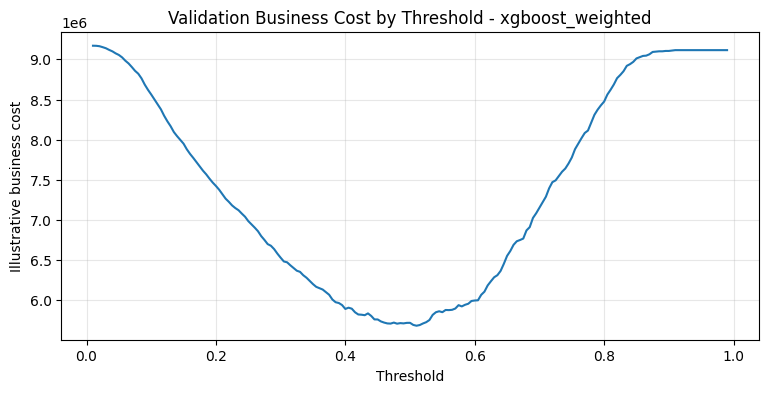

In [6]:
champion_grid = validation_threshold_grid.loc[
    validation_threshold_grid["model_name"].eq(champion_model_name)
].copy()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(champion_grid["threshold"], champion_grid["business_cost"])
ax.set_title(f"Validation Business Cost by Threshold - {champion_model_name}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Illustrative business cost")
ax.grid(True, alpha=0.3)
plt.show()

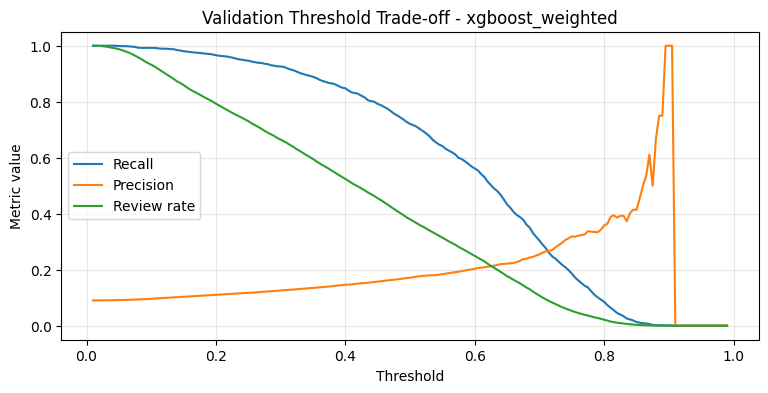

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(champion_grid["threshold"], champion_grid["recall"], label="Recall")
ax.plot(champion_grid["threshold"], champion_grid["precision"], label="Precision")
ax.plot(champion_grid["threshold"], champion_grid["review_rate"], label="Review rate")
ax.set_title(f"Validation Threshold Trade-off - {champion_model_name}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Metric value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Select recommended operating threshold

For this portfolio project, the recommended threshold uses the **minimum-cost threshold subject to a 30% review-rate cap**.

This is more realistic than simply choosing the absolute minimum-cost threshold, because credit-review teams usually have limited capacity and customer-friction costs are not fully captured by simple false-positive cost assumptions.

In [8]:
recommended_threshold = recommend_operating_threshold(
    champion_validation_shortlist,
    preferred_objective="minimum_cost_review_rate_le_30pct",
)

pd.DataFrame([recommended_threshold])[display_cols]

,objective,threshold,business_cost,recall,precision,f1,mcc,review_rate,true_positive,false_positive,false_negative,true_negative
6,minimum_cost_review_rate_le_30pct,0.565,5882500.0,0.619309,0.18962,0.290343,0.223938,0.295293,1129,4825,694,13515


## Apply validation-selected thresholds to the test split

The test split is used only after candidate thresholds have been selected from validation data. This gives a cleaner view of out-of-sample operating performance.

In [9]:
champion_test_shortlist = apply_thresholds_to_dataset(
    threshold_shortlist=champion_validation_shortlist,
    threshold_grid=test_threshold_grid,
    model_name=champion_model_name,
    dataset_name="test",
)

champion_test_shortlist[display_cols]

,objective,threshold,business_cost,recall,precision,f1,mcc,review_rate,true_positive,false_positive,false_negative,true_negative
0,default_threshold_0_50,0.500,5656500.0,0.727372,0.172904,0.279393,0.225365,0.380350,1326,6343,497,11997
1,minimum_business_cost,0.510,5695000.0,0.709819,0.175007,0.280786,0.224471,0.366711,1294,6100,529,12240
2,maximum_f1,0.605,6093500.0,0.541415,0.205027,0.297424,0.223827,0.238754,987,3827,836,14513
3,maximum_mcc,0.605,6093500.0,0.541415,0.205027,0.297424,0.223827,0.238754,987,3827,836,14513
4,maximum_balanced_accuracy,0.510,5695000.0,0.709819,0.175007,0.280786,0.224471,0.366711,1294,6100,529,12240
5,minimum_cost_review_rate_le_25pct,0.600,6051000.0,0.552386,0.203475,0.297401,0.224863,0.245450,1007,3942,816,14398
6,minimum_cost_review_rate_le_30pct,0.565,5884500.0,0.614920,0.190971,0.291434,0.224717,0.291127,1121,4749,702,13591
7,minimum_cost_review_rate_le_35pct,0.525,5745000.0,0.682392,0.179147,0.283791,0.224264,0.344393,1244,5700,579,12640
8,minimum_cost_review_rate_le_40pct,0.510,5695000.0,0.709819,0.175007,0.280786,0.224471,0.366711,1294,6100,529,12240
9,minimum_cost_recall_ge_60pct,0.510,5695000.0,0.709819,0.175007,0.280786,0.224471,0.366711,1294,6100,529,12240


## Save threshold outputs

These outputs will feed Notebook 09 model governance and the final stakeholder summary.

In [10]:
save_threshold_outputs(
    table_dir=TABLE_DIR,
    validation_grid=validation_threshold_grid,
    test_grid=test_threshold_grid,
    validation_shortlist=champion_validation_shortlist,
    test_shortlist=champion_test_shortlist,
    recommendation=recommended_threshold,
    cost_assumptions=cost_assumptions,
)

saved_outputs = {
    "validation_threshold_grid": str(TABLE_DIR / "threshold_grid_validation_all_models.csv"),
    "test_threshold_grid": str(TABLE_DIR / "threshold_grid_test_all_models.csv"),
    "validation_shortlist": str(TABLE_DIR / "champion_threshold_shortlist_validation.csv"),
    "test_shortlist": str(TABLE_DIR / "champion_threshold_shortlist_test.csv"),
    "recommended_threshold": str(TABLE_DIR / "recommended_threshold_summary.csv"),
    "cost_assumptions": str(TABLE_DIR / "business_cost_assumptions.csv"),
}
saved_outputs

{'validation_threshold_grid': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\threshold_grid_validation_all_models.csv',
 'test_threshold_grid': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\threshold_grid_test_all_models.csv',
 'validation_shortlist': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\champion_threshold_shortlist_validation.csv',
 'test_shortlist': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\champion_threshold_shortlist_test.csv',
 'recommended_threshold': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\recommended_threshold_summary.csv',
 'cost_assumptions': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\business_cost_assumptions.csv'}

## Recommended Operating Threshold

| Area | Result |
|---|---:|
| Objective | `minimum_cost_review_rate_le_30pct` |
| Recommended threshold | 0.565 |

## Validation Result

| Metric | Result |
|---|---:|
| Recall | 61.93% |
| Precision | 18.96% |
| Review rate | 29.53% |
| Business cost | $5,882,500 |

## Test Result

| Metric | Result |
|---|---:|
| Recall | 61.49% |
| Precision | 19.10% |
| Review rate | 29.11% |
| Business cost | $5,884,500 |

## Business Interpretation

This is a strong portfolio decision because it reduces the manual review workload from approximately 38% at the default `0.50` threshold to about 29%, while still capturing approximately 61% of defaults.

This threshold is more realistic for credit-risk operations than blindly using the default model cutoff, because it balances default detection with operational review capacity.

## Notebook 07 conclusions

Carry these decisions forward:

1. The champion model remains selected from Notebook 06 based on validation ranking performance.
2. The default 0.50 cutoff is not automatically the best business threshold.
3. The preferred operating threshold should balance missed-default cost, review capacity, and customer impact.
4. The selected threshold should be documented as a governance decision and reviewed if portfolio mix, default rate, or operational capacity changes.
5. Notebook 08 will explain the champion model using SHAP and local explanations.